In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image

In [15]:
# 여러 PyTorch transforms의 전처리 함수들을 순서대로 묶어 하나의 파이프라인으로 만든다.
# 아래 dataset에서 transform으로 지정하면, 파이프라인에 지정된 순서대로 변환된다.

transform = transforms.Compose([
    transforms.ToTensor(),  # PIL Image, Numpy array -> PyTorch Tensor
    transforms.Normalize((0.5,), (0.5,))  # (mean, std)를 인자로 받아 정규화, output = (input - mean) / std
])

In [16]:
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

In [17]:
with open('./datasets/mnist/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./datasets/mnist/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    labels = np.fromfile(f, dtype=np.uint8)

with open('./datasets/mnist/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./datasets/mnist/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

images = images.astype(np.float32) / 255.0
test_images  = test_images.astype(np.float32)  / 255.0

train_dataset = CustomDataset(images, labels)
test_dataset = CustomDataset(test_images, test_labels)

# batch_size를 지정하는 Mini-batch 방식을 통해 학습, shuffle로 매 epoch마다 학습 데이터를 무작위 배치
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

In [18]:
print(len(train_dataset))  
print(len(test_dataset))   

60000
10000


In [19]:
class ANN(nn.Module):  # nn.Module: PyTorch 신경망 모듈 base class 상속
    def __init__(self):
        super().__init__()  # nn.Module 생성자 호출

        self.fc = nn.Sequential(
            nn.Flatten(),  # 2D tensor -> 1D tensor | [batch, 1, 28, 28] → [batch, 784]

            nn.Linear(784, 512),  # 784 -> 512 -> 256 -> 128 -> 10 으로 뉴런 수를 줄이면서 핵심 패턴만 학습하도록 모델의 vector 자체를 줄여나간다.
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):  # nn.Module forward() overriding
        return self.fc(x)

model = ANN()

In [20]:
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss function
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer, learning rate: 0.001

In [21]:
train_losses, test_losses         = [], []
train_accuracies, test_accuracies = [], []

In [22]:
epochs = 10

for epoch in range(epochs):

    # ── Train ──
    model.train()  # 모델 학습 진행
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        optimizer.zero_grad()  # .grad 초기화
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()  # loss값을 통해 현재 기울기를 계산하여 파라미터 값을 .grad에 저장
        optimizer.step() # .grad 값을 기반으로 최적의 파라미터 계산 후 가중치 업데이트

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)

    # ── Test ──
    model.eval()  # 모델 추론 진행
    test_loss, correct_test, total_test = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs   = model(images)
            loss      = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted  = torch.max(outputs, 1)
            total_test   += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct_test / total_test)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_losses[-1]:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f} | "
          f"Train Acc: {train_accuracies[-1]:.2f}% | "
          f"Test Acc: {test_accuracies[-1]:.2f}%")

Epoch [1/10] Train Loss: 0.3277 | Test Loss: 0.1213 | Train Acc: 89.84% | Test Acc: 96.35%
Epoch [2/10] Train Loss: 0.1387 | Test Loss: 0.0975 | Train Acc: 95.90% | Test Acc: 97.03%
Epoch [3/10] Train Loss: 0.1069 | Test Loss: 0.0790 | Train Acc: 96.83% | Test Acc: 97.56%
Epoch [4/10] Train Loss: 0.0893 | Test Loss: 0.0850 | Train Acc: 97.41% | Test Acc: 97.57%
Epoch [5/10] Train Loss: 0.0757 | Test Loss: 0.0671 | Train Acc: 97.64% | Test Acc: 98.04%
Epoch [6/10] Train Loss: 0.0668 | Test Loss: 0.0602 | Train Acc: 98.00% | Test Acc: 98.23%
Epoch [7/10] Train Loss: 0.0606 | Test Loss: 0.0689 | Train Acc: 98.11% | Test Acc: 98.08%
Epoch [8/10] Train Loss: 0.0552 | Test Loss: 0.0659 | Train Acc: 98.32% | Test Acc: 98.14%
Epoch [9/10] Train Loss: 0.0531 | Test Loss: 0.0599 | Train Acc: 98.39% | Test Acc: 98.40%
Epoch [10/10] Train Loss: 0.0475 | Test Loss: 0.0658 | Train Acc: 98.59% | Test Acc: 98.32%


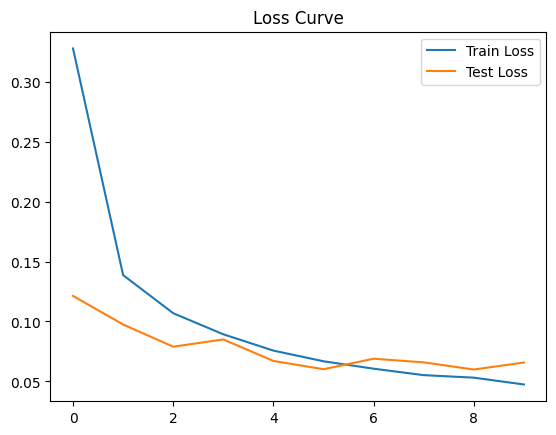

In [23]:
plt.figure()
plt.plot(train_losses,     label="Train Loss")
plt.plot(test_losses,      label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

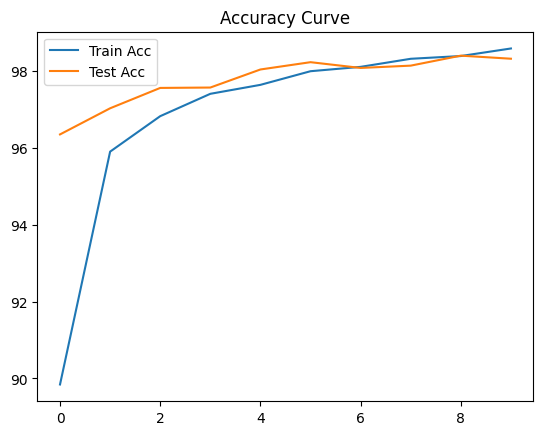

In [24]:
plt.figure()
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies,  label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

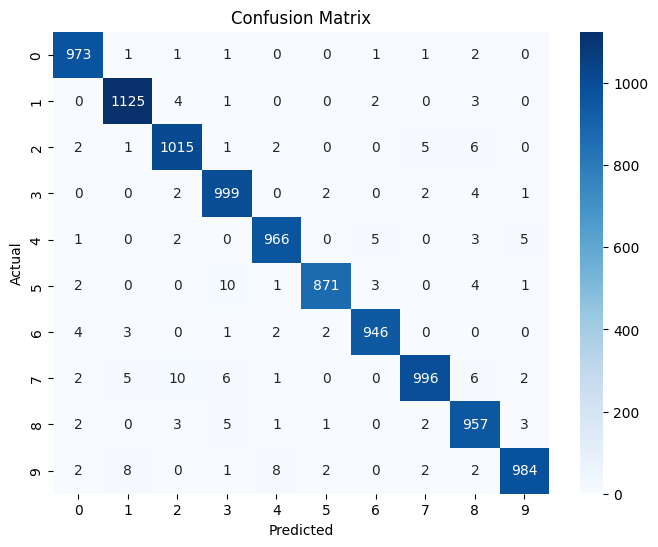

In [25]:
all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        _, predicted = torch.max(model(images), 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

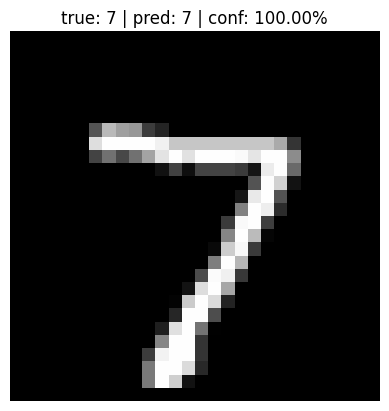

In [26]:
model.eval()
images, labels = next(iter(test_loader))

single_image = images[0].unsqueeze(0)
true_label   = labels[0].item()

with torch.no_grad():
    output          = model(single_image)
    probabilities   = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()
    confidence      = probabilities[0][predicted_label].item()

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"true: {true_label} | pred: {predicted_label} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()